In [1]:
%load_ext autoreload
%autoreload 2
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import sys
import importlib
import coffea.util as util
import time
import json
import os
import numba as nb
import awkward.numba

sys.path.append("../analysisTools/")
from analysisTools import Analyzer
from analysisTools import loadSchema
import analysisTools as tools
import analysisSubroutines as routines

In [2]:
sample_cfg = "../configs/sample_configs/signal_2022_Mchi_10_30_50_aEM.json"
with open(sample_cfg,"r") as fin:
    sig_cfg = json.load(fin)

In [3]:
loc = sig_cfg[1]['location']
loc

'/uscms/home/reshmar/nobackup/CMSSW_13_0_13/src/iDMe/AODSkimmer/signal_files_2022/Signal_Mchi-31p5_dMchi-3p0_ctau-10_output.root'

In [24]:
#See the qu
t = uproot.open(loc)['ntuples/outT']
#print("\n".join(t.keys()))

In [22]:
pfjet_keys = [key for key in t.keys() if "Calo" in key]
#print("\n".join(pfjet_keys))

In [23]:
# Triggers
met_trig=t["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
print(met_trig)
print (len(met_trig))
# ref_trig_1 = t["trig_HLT_DoubleEle27_CaloIdL_MW"].array()
# print(ref_trig_1)
# ref_trig_2 = t["trig_HLT_Ele32_WPTight_Gsf"].array()
# print(ref_trig_2)

[False, False, False, True, True, False, ... False, False, True, False, False, True]
67154


In [7]:
#cuts applied
PFMET_pt=t["PFMET_pt"].array()
print (PFMET_pt)

CaloMET_pt=t["CaloMET_pt"].array()
print (CaloMET_pt)
diff= abs(PFMET_pt-CaloMET_pt)
print (diff)

r=diff/(CaloMET_pt)
print(r)

cut_sig=(r <0.5)
print(len(cut_sig))

[100, 83.4, 97, 173, 205, 104, 104, 145, ... 156, 86.5, 149, 135, 141, 166, 107, 186]
[73.2, 60.7, 106, 173, 180, 96.1, 83, 85.1, ... 77.9, 122, 65.4, 141, 120, 77.1, 159]
[27.1, 22.7, 8.79, 0.289, 25.7, 8.01, 20.7, ... 27.5, 69.9, 0.357, 45.8, 30, 27.1]
[0.371, 0.373, 0.0831, 0.00167, 0.143, ... 1.07, 0.00253, 0.382, 0.389, 0.171]
67154


In [8]:
pfmet_pass = PFMET_pt[cut_sig]
print(pfmet_pass)
len(pfmet_pass)

[100, 83.4, 97, 173, 205, 104, 104, 109, ... 156, 86.5, 149, 141, 166, 107, 186]


53975

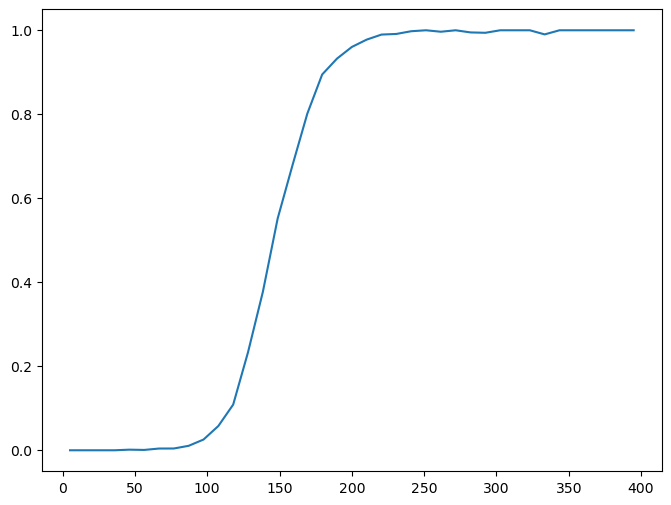

In [20]:
met_trig_pass = met_trig[cut_sig]  
pfmet_pass = PFMET_pt[cut_sig]

bins = np.linspace(0, 400, 40)  

deno, edges_deno = np.histogram(pfmet_pass, bins=bins)
# print ("deno:", deno)
# print ("edges_deno:", edges_deno)
nume, edges_nume = np.histogram(pfmet_pass[met_trig_pass], bins=bins)

eff_y= np.divide(nume, deno)  #Efficiency per bin

#For PFMET, the number has to be per bin
values_x, edges_x= np.histogram(PFMET_pt, bins=bins)

pfmet_bin_x=0.5 * (edges_x[:-1] + edges_x[1:])
#print (pfmet_bin_x)

plt.figure(figsize=(8,6))
plt.plot(pfmet_bin_x,eff_y)

In [ ]:
# plt.figure(figsize=(6,6))
# bins = np.linspace(0,400,400)
# h1 = plt.hist(t['PFMET_pt'].array(),bins=bins,histtype='step',label='PFMET_pt')
# plt.xlabel("$p_Tmiss$ [GeV]")
# plt.legend()